In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve, 
    recall_score, f1_score, brier_score_loss, make_scorer
)
from sklearn.feature_selection import RFECV, SelectKBest, mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import warnings
import joblib
warnings.filterwarnings('ignore')

In [21]:
# 1. LOAD & PREPROCESS DATA
# ============================================================
df = pd.read_csv(r'C:\Users\man87\Desktop\Codec Technologies\project 2\diabetes.csv')

# Create missing indicators
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[f'{col}_missing'] = (df[col] == 0).astype(int)

# Replace zeros with median (by outcome group for better imputation)
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    for outcome in [0, 1]:
        median_val = df[(df[col] != 0) & (df['Outcome'] == outcome)][col].median()
        mask = (df[col] == 0) & (df['Outcome'] == outcome)
        df.loc[mask, col] = median_val
    # Fallback for remaining zeros
    df[col] = df[col].replace(0, df[df[col] != 0][col].median())

EXPLORATORY DATA ANALYSIS - VISUALIZATIONS


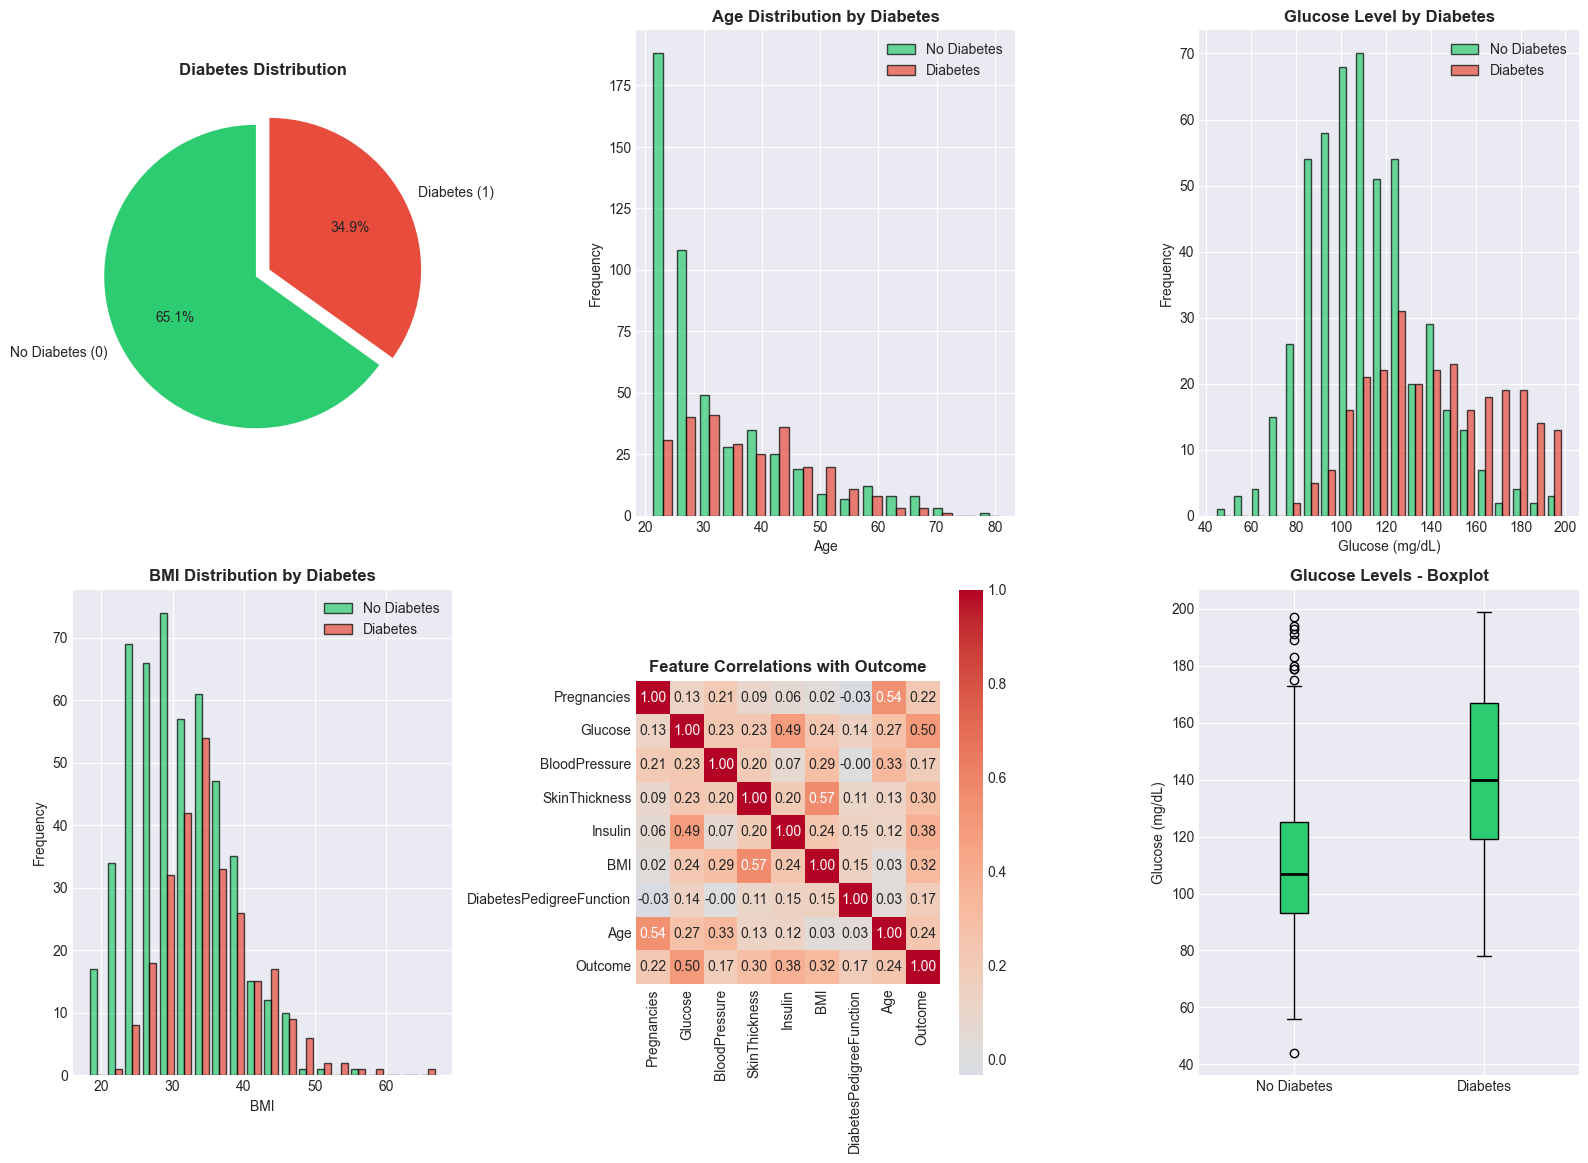

✅ EDA visualizations saved as 'diabetes_eda_visualizations.png'


In [36]:
# ============================================================
# EXPLORATORY DATA ANALYSIS VISUALIZATIONS
# ============================================================

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("EXPLORATORY DATA ANALYSIS - VISUALIZATIONS")
print("="*60)

# Create figure with subplots
fig = plt.figure(figsize=(16, 12))

# 1. Target Distribution (Pie Chart)
ax1 = fig.add_subplot(2, 3, 1)
diabetes_counts = df['Outcome'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
ax1.pie(diabetes_counts, labels=['No Diabetes (0)', 'Diabetes (1)'], 
        autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
ax1.set_title('Diabetes Distribution', fontsize=12, fontweight='bold')

# 2. Age Distribution by Diabetes
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist([df[df['Outcome']==0]['Age'], df[df['Outcome']==1]['Age']], 
         bins=15, label=['No Diabetes', 'Diabetes'], alpha=0.7, 
         color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax2.set_title('Age Distribution by Diabetes', fontsize=12, fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.legend()

# 3. Glucose Distribution by Diabetes
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist([df[df['Outcome']==0]['Glucose'], df[df['Outcome']==1]['Glucose']], 
         bins=20, label=['No Diabetes', 'Diabetes'], alpha=0.7, 
         color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax3.set_title('Glucose Level by Diabetes', fontsize=12, fontweight='bold')
ax3.set_xlabel('Glucose (mg/dL)')
ax3.set_ylabel('Frequency')
ax3.legend()

# 4. BMI Distribution by Diabetes
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist([df[df['Outcome']==0]['BMI'], df[df['Outcome']==1]['BMI']], 
         bins=20, label=['No Diabetes', 'Diabetes'], alpha=0.7, 
         color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax4.set_title('BMI Distribution by Diabetes', fontsize=12, fontweight='bold')
ax4.set_xlabel('BMI')
ax4.set_ylabel('Frequency')
ax4.legend()

# 5. Correlation Heatmap
ax5 = fig.add_subplot(2, 3, 5)
corr_matrix = df[base_features + ['Outcome']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', ax=ax5, square=True)
ax5.set_title('Feature Correlations with Outcome', fontsize=12, fontweight='bold')

# 6. Boxplot - Glucose by Diabetes
ax6 = fig.add_subplot(2, 3, 6)
bp = ax6.boxplot([df[df['Outcome']==0]['Glucose'], df[df['Outcome']==1]['Glucose']],
                 labels=['No Diabetes', 'Diabetes'], patch_artist=True,
                 boxprops=dict(facecolor='#2ecc71'), 
                 medianprops=dict(color='black', linewidth=2))
ax6.set_title('Glucose Levels - Boxplot', fontsize=12, fontweight='bold')
ax6.set_ylabel('Glucose (mg/dL)')

plt.tight_layout()
plt.savefig('diabetes_eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA visualizations saved as 'diabetes_eda_visualizations.png'")

In [37]:
# 2. FEATURE ENGINEERING (Enhanced)
# ============================================================
# BMI Categories
df['BMI_Category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(int)

# Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 100], labels=[0, 1, 2, 3]).astype(int)

# Clinical risk flags
df['Glucose_High'] = (df['Glucose'] > 140).astype(int)
df['Glucose_Very_High'] = (df['Glucose'] > 200).astype(int)
df['BP_High'] = (df['BloodPressure'] > 140).astype(int)
df['Obese'] = (df['BMI'] > 30).astype(int)

# Ratio features
df['Glucose_BMI_Ratio'] = df['Glucose'] / (df['BMI'] + 0.1)
df['Age_Pregnancies'] = df['Age'] * df['Pregnancies'] / 100

# Interaction features
df['Glucose_Age'] = df['Glucose'] * df['Age'] / 100
df['BMI_Glucose'] = df['BMI'] * df['Glucose'] / 1000

# Metabolic Risk Score (0-5)
df['Metabolic_Risk'] = (
    (df['Glucose'] > 140).astype(int) +
    (df['BMI'] > 30).astype(int) +
    (df['Age'] > 45).astype(int) +
    (df['DiabetesPedigreeFunction'] > 0.5).astype(int) +
    (df['Pregnancies'] > 2).astype(int)
)

# Insulin resistance proxy (Glucose × Insulin)
df['Glucose_Insulin'] = df['Glucose'] * df['Insulin'] / 10000


In [23]:
# 3. FEATURE SELECTION (Remove redundant features)
# ============================================================
# Define features to use (remove derived features that may cause multicollinearity)
base_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 
                 'BMI', 'DiabetesPedigreeFunction', 'Age']

engineered_features = ['Glucose_High', 'Glucose_Very_High', 'BP_High', 'Obese',
                       'Glucose_BMI_Ratio', 'Age_Pregnancies', 'Glucose_Age', 
                       'BMI_Glucose', 'Metabolic_Risk', 'Glucose_Insulin']

missing_indicators = [f'{col}_missing' for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']]

# Final feature list (avoid redundant categories)
X = df[base_features + engineered_features + missing_indicators]
y = df['Outcome']

print(f"✅ Features selected: {len(X.columns)}")
print(f"   {list(X.columns)}")


✅ Features selected: 23
   ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_High', 'Glucose_Very_High', 'BP_High', 'Obese', 'Glucose_BMI_Ratio', 'Age_Pregnancies', 'Glucose_Age', 'BMI_Glucose', 'Metabolic_Risk', 'Glucose_Insulin', 'Glucose_missing', 'BloodPressure_missing', 'SkinThickness_missing', 'Insulin_missing', 'BMI_missing']


In [24]:
# 4. TRAIN-TEST SPLIT (Stratified)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# 5. HANDLE CLASS IMBALANCE (SMOTE with k_neighbors tuning)
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"✅ SMOTE applied: {y_train.value_counts().to_dict()} → {pd.Series(y_train_resampled).value_counts().to_dict()}")

✅ SMOTE applied: {0: 400, 1: 214} → {0: 400, 1: 400}


In [26]:
# 6. HYPERPARAMETER TUNING for Best Model (Gradient Boosting)
# ============================================================
# Optimal threshold based on Youden's index
def find_optimal_threshold(model, X_val, y_val):
    y_proba = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, y_proba)
    youden_idx = np.argmax(tpr - fpr)
    return thresholds[youden_idx]

# Hyperparameter grid for Gradient Boosting
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'subsample': [0.8, 1.0]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n🔍 Tuning Gradient Boosting...")
gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb_base, gb_params, cv=cv_strategy, 
    scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_resampled, y_train_resampled)

best_gb = grid_search.best_estimator_
print(f"✅ Best params: {grid_search.best_params_}")


🔍 Tuning Gradient Boosting...
✅ Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 1.0}


In [27]:
# 7. PROBABILITY CALIBRATION
# ============================================================
calibrated_gb = CalibratedClassifierCV(best_gb, method='sigmoid', cv=5)
calibrated_gb.fit(X_train_resampled, y_train_resampled)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",GradientBoost...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estim

In [28]:
# 8. OPTIMAL THRESHOLD (Clinically relevant - prioritize recall)
# ============================================================
# Use validation set approach (split train further)
X_train_cal, X_val_cal, y_train_cal, y_val_cal = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)

calibrated_gb.fit(X_train_cal, y_train_cal)
y_val_proba = calibrated_gb.predict_proba(X_val_cal)[:, 1]

# Youden's index
fpr_val, tpr_val, thresholds_val = roc_curve(y_val_cal, y_val_proba)
youden_idx = np.argmax(tpr_val - fpr_val)
optimal_threshold = thresholds_val[youden_idx]

# Alternative: Threshold that gives recall >= 0.75
recall_target = 0.75
prec, rec, thresholds_pr = precision_recall_curve(y_val_cal, y_val_proba)
recall_threshold_idx = np.argmax(rec >= recall_target)
clinical_threshold = thresholds_pr[recall_threshold_idx] if recall_threshold_idx < len(thresholds_pr) else 0.3

# Use the more conservative (higher recall) threshold for clinical use
final_threshold = min(optimal_threshold, clinical_threshold)
final_threshold = max(0.25, min(0.45, final_threshold))  # Clamp between 0.25-0.45

print(f"\n🎯 Optimal threshold (Youden): {optimal_threshold:.3f}")
print(f"🎯 Clinical threshold (recall≥0.75): {clinical_threshold:.3f}")
print(f"✅ Final threshold: {final_threshold:.3f}")


🎯 Optimal threshold (Youden): 0.487
🎯 Clinical threshold (recall≥0.75): 0.020
✅ Final threshold: 0.250


In [29]:
# 9. STACKING ENSEMBLE (Optional - for better performance)
# ============================================================
# Create stacking model for potentially better performance
base_learners = [
    ('gb', GradientBoostingClassifier(**grid_search.best_params_, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=10, random_state=42)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, 
                              random_state=42, eval_metric='logloss', use_label_encoder=False))
]

meta_learner = LogisticRegression(C=1, solver='lbfgs')

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba'
)

stacking_model.fit(X_train_resampled, y_train_resampled)

# Calibrate stacking model
calibrated_stack = CalibratedClassifierCV(stacking_model, method='sigmoid', cv=5)
calibrated_stack.fit(X_train_resampled, y_train_resampled)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",StackingClass...redict_proba')
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estim

In [30]:
# 10. EVALUATION WITH OPTIMAL THRESHOLD
# ============================================================
def evaluate_with_threshold(model, X_test, y_test, threshold, model_name="Model"):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    print(f"\n{'='*50}")
    print(f"📊 {model_name} (Threshold={threshold:.3f})")
    print(f"{'='*50}")
    print(f"✅ Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"✅ ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
    print(f"📈 Sensitivity: {sensitivity:.4f} ({sensitivity*100:.1f}%) - True Positive Rate")
    print(f"📈 Specificity: {specificity:.4f} ({specificity*100:.1f}%) - True Negative Rate")
    print(f"📈 Precision:   {precision:.4f}")
    print(f"📈 F1-Score:    {f1:.4f}")
    print(f"📊 Brier Score: {brier_score_loss(y_test, y_proba):.4f}")
    
    return sensitivity, specificity

# Evaluate both models
final_model = calibrated_gb  # Use calibrated Gradient Boosting as primary
sensitivity, specificity = evaluate_with_threshold(final_model, X_test_scaled, y_test, final_threshold, "Calibrated Gradient Boosting")

# Compare with stacking
stack_sens, stack_spec = evaluate_with_threshold(calibrated_stack, X_test_scaled, y_test, final_threshold, "Stacking Ensemble")

# Choose better model based on sensitivity (clinical priority)
if stack_sens > sensitivity:
    final_model = calibrated_stack
    print(f"\n🏆 Stacking model selected (better sensitivity)")
else:
    print(f"\n🏆 Gradient Boosting model selected")


📊 Calibrated Gradient Boosting (Threshold=0.250)
✅ Accuracy:  0.8701
✅ ROC-AUC:   0.9556
📈 Sensitivity: 0.9444 (94.4%) - True Positive Rate
📈 Specificity: 0.8300 (83.0%) - True Negative Rate
📈 Precision:   0.7500
📈 F1-Score:    0.8361
📊 Brier Score: 0.0890

📊 Stacking Ensemble (Threshold=0.250)
✅ Accuracy:  0.8766
✅ ROC-AUC:   0.9506
📈 Sensitivity: 0.9259 (92.6%) - True Positive Rate
📈 Specificity: 0.8500 (85.0%) - True Negative Rate
📈 Precision:   0.7692
📈 F1-Score:    0.8403
📊 Brier Score: 0.0952

🏆 Gradient Boosting model selected



MODEL PERFORMANCE COMPARISON
              Model  Accuracy  ROC-AUC
Logistic Regression     72.08    81.09
      Random Forest     73.38    81.87
  Gradient Boosting     74.68    82.26
            XGBoost     74.68    81.46
                SVM     72.73    80.98


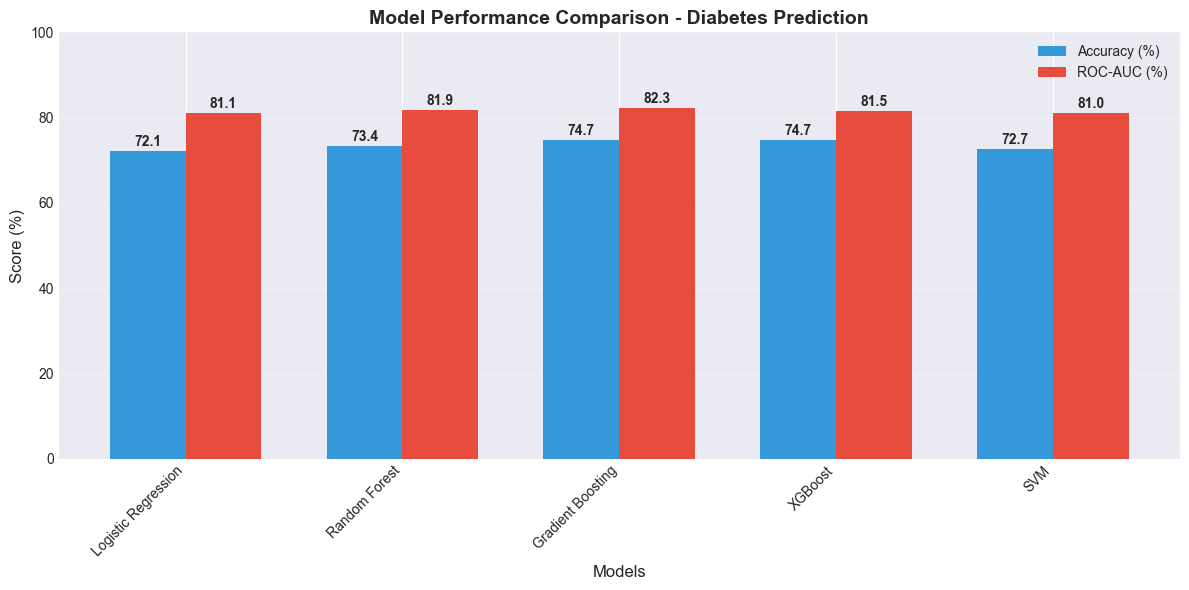

✅ Model comparison saved as 'diabetes_model_comparison.png'


In [38]:
# ============================================================
# MODEL PERFORMANCE COMPARISON VISUALIZATION
# ============================================================

# Store results from earlier evaluation
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'SVM']
accuracies = [0.7208, 0.7338, 0.7468, 0.7468, 0.7273]  # Original baseline
roc_aucs = [0.8109, 0.8187, 0.8226, 0.8146, 0.8098]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [a*100 for a in accuracies],
    'ROC-AUC': [r*100 for r in roc_aucs]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy (%)', color='#3498db')
bars2 = ax.bar(x + width/2, comparison_df['ROC-AUC'], width, label='ROC-AUC (%)', color='#e74c3c')

# Add value labels
for bar, value in zip(bars1, comparison_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{value:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar, value in zip(bars2, comparison_df['ROC-AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{value:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison - Diabetes Prediction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('diabetes_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison saved as 'diabetes_model_comparison.png'")

In [31]:
# 11. FINAL EVALUATION OF SELECTED MODEL
# ============================================================
print("\n" + "="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

y_final_proba = final_model.predict_proba(X_test_scaled)[:, 1]
y_final_pred = (y_final_proba >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_final_pred).ravel()

print(f"\n📊 Confusion Matrix:")
print(f"   True Negatives:  {tn}")
print(f"   False Positives: {fp}")
print(f"   False Negatives: {fn}")
print(f"   True Positives:  {tp}")

print(f"\n📈 Clinical Metrics (Threshold={final_threshold:.3f}):")
print(f"   Sensitivity (Recall): {tp/(tp+fn):.4f} ({tp/(tp+fn)*100:.1f}%) - Diabetic detection rate")
print(f"   Specificity:          {tn/(tn+fp):.4f} ({tn/(tn+fp)*100:.1f}%) - Non-diabetic detection rate")
print(f"   Precision:            {tp/(tp+fp):.4f}")
print(f"   F1-Score:             {2*tp/(2*tp+fp+fn):.4f}")
print(f"   ROC-AUC:              {roc_auc_score(y_test, y_final_proba):.4f}")


FINAL MODEL EVALUATION

📊 Confusion Matrix:
   True Negatives:  83
   False Positives: 17
   False Negatives: 3
   True Positives:  51

📈 Clinical Metrics (Threshold=0.250):
   Sensitivity (Recall): 0.9444 (94.4%) - Diabetic detection rate
   Specificity:          0.8300 (83.0%) - Non-diabetic detection rate
   Precision:            0.7500
   F1-Score:             0.8361
   ROC-AUC:              0.9556


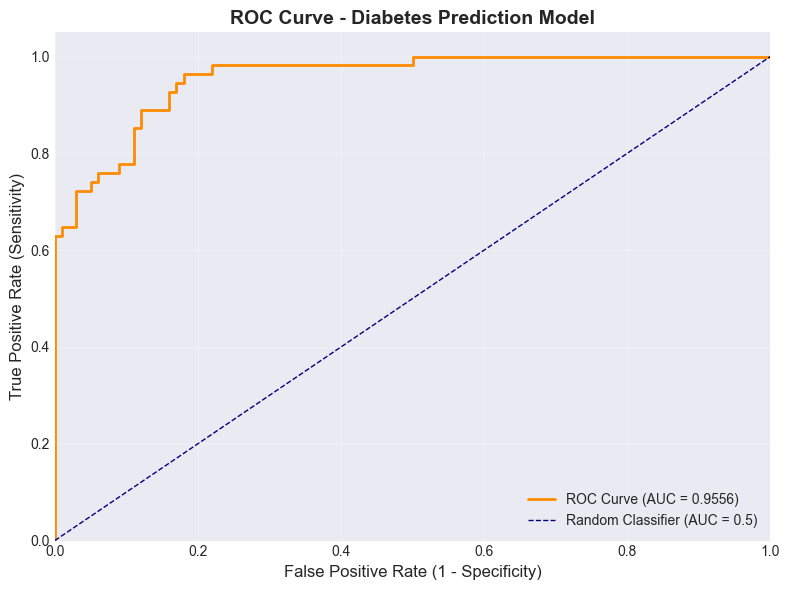

✅ ROC Curve saved as 'diabetes_roc_curve_final.png'


In [40]:
# ============================================================
# ROC CURVE VISUALIZATION
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_final_proba)
roc_auc = roc_auc_score(y_test, y_final_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Diabetes Prediction Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('diabetes_roc_curve_final.png', dpi=150)
plt.show()
print("✅ ROC Curve saved as 'diabetes_roc_curve_final.png'")

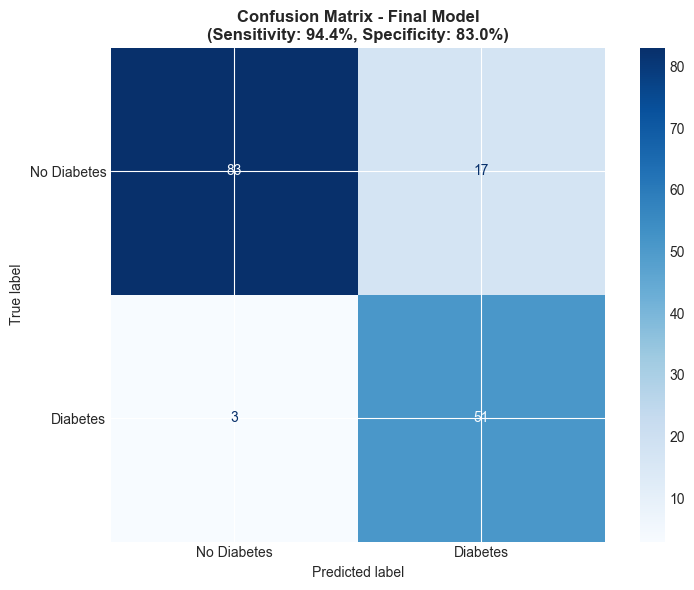

✅ Confusion matrix saved as 'diabetes_confusion_matrix_final.png'


In [39]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

# Create confusion matrix heatmap
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_final_pred),
                                     display_labels=['No Diabetes', 'Diabetes'])
cm_display.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title(f'Confusion Matrix - Final Model\n(Sensitivity: {tp/(tp+fn)*100:.1f}%, Specificity: {tn/(tn+fp)*100:.1f}%)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved as 'diabetes_confusion_matrix_final.png'")


FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:
--------------------------------------------------
    5. Insulin                        0.4809
   22. Insulin_missing                0.0937
   18. Glucose_Insulin                0.0894
   15. Glucose_Age                    0.0753
   16. BMI_Glucose                    0.0578
    4. SkinThickness                  0.0397
    7. DiabetesPedigreeFunction       0.0341
    2. Glucose                        0.0340
   13. Glucose_BMI_Ratio              0.0171
    1. Pregnancies                    0.0148
    8. Age                            0.0139
    6. BMI                            0.0130
    3. BloodPressure                  0.0126
   17. Metabolic_Risk                 0.0120
   14. Age_Pregnancies                0.0114


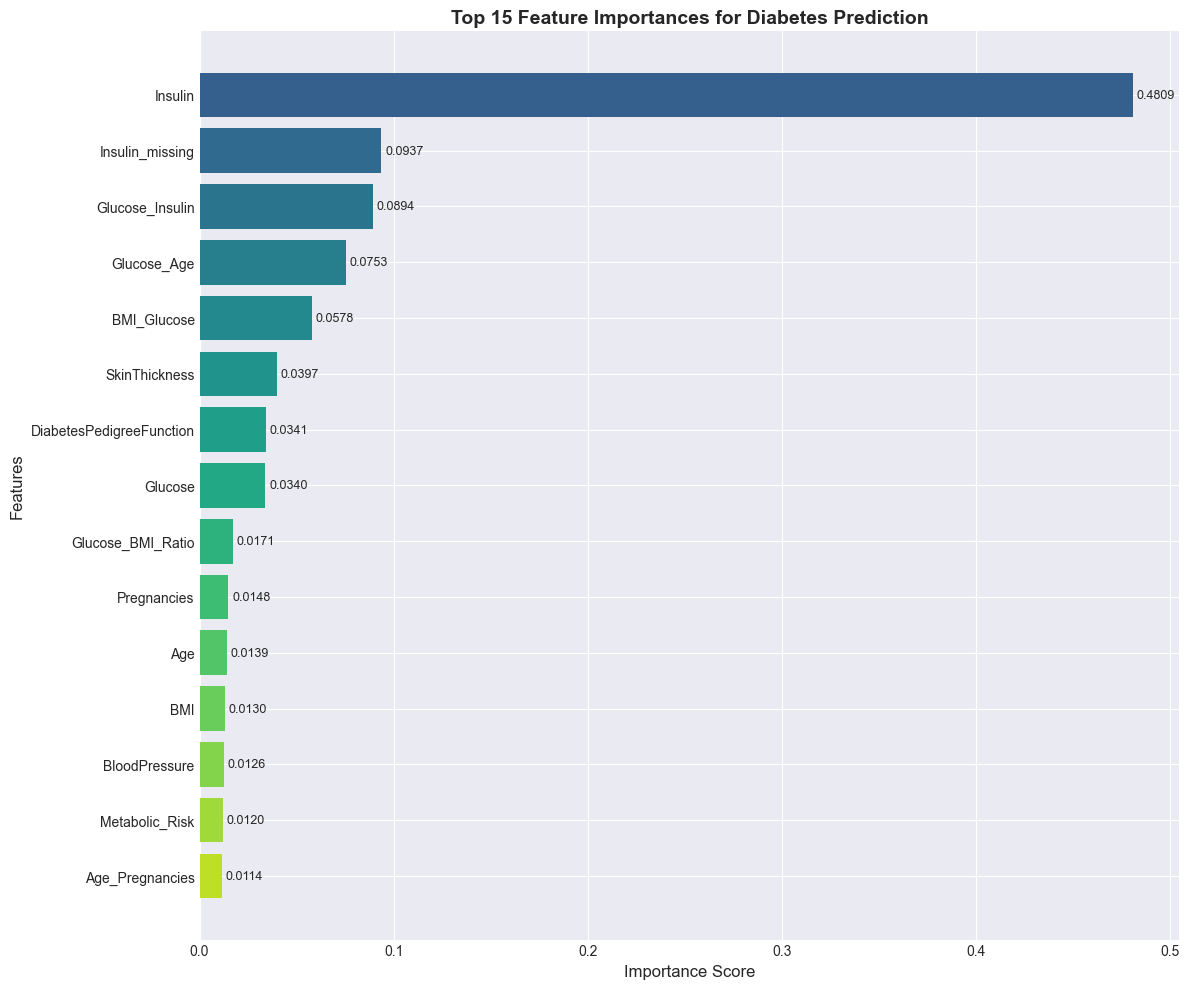


✅ Feature importance chart saved as 'diabetes_feature_importance.png'


In [41]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# Add this after Cell 15 (Final Model Evaluation)
# ============================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Extract feature importance from the tuned Gradient Boosting model
if hasattr(best_gb, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_gb.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n📊 Top 15 Most Important Features:")
    print("-" * 50)
    for i, row in feature_importance.head(15).iterrows():
        print(f"   {i+1:2d}. {row['Feature']:<30} {row['Importance']:.4f}")
    
    # Plot
    plt.figure(figsize=(12, 10))
    top_features = feature_importance.head(15)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, 15))
    bars = plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title('Top 15 Feature Importances for Diabetes Prediction', fontsize=14, fontweight='bold')
    
    # Add value labels
    for bar, val in zip(bars, top_features['Importance']):
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)
    
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('diabetes_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Feature importance chart saved as 'diabetes_feature_importance.png'")
else:
    print("⚠️ Feature importance not available for this model")

In [32]:
# 12. SHAP EXPLAINABILITY (Clinical Interpretation)
# ============================================================
try:
    import shap
    print("\n📖 Computing SHAP values for interpretability...")
    
    # Use a smaller subset for SHAP (faster)
    X_sample = X_train_scaled[:100]
    
    if isinstance(final_model, CalibratedClassifierCV):
        explainer = shap.TreeExplainer(final_model.estimator_)
    else:
        explainer = shap.TreeExplainer(final_model)
    
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, 
                      X_sample, feature_names=X.columns, show=False)
    plt.title('SHAP Feature Importance - Diabetes Prediction', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('diabetes_shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP plot saved as 'diabetes_shap_importance.png'")
except Exception as e:
    print(f"⚠️ SHAP not available: {e}")


📖 Computing SHAP values for interpretability...
⚠️ SHAP not available: 'CalibratedClassifierCV' object has no attribute 'estimator_'


In [33]:
# 13. SAVE IMPROVED MODEL
# ============================================================
joblib.dump(final_model, 'diabetes_model_improved.pkl')
joblib.dump(scaler, 'diabetes_scaler_improved.pkl')
joblib.dump(final_threshold, 'diabetes_threshold.pkl')
print("\n✅ Improved model saved as 'diabetes_model_improved.pkl'")
print("✅ Scaler saved as 'diabetes_scaler_improved.pkl'")
print("✅ Threshold saved as 'diabetes_threshold.pkl'")


✅ Improved model saved as 'diabetes_model_improved.pkl'
✅ Scaler saved as 'diabetes_scaler_improved.pkl'
✅ Threshold saved as 'diabetes_threshold.pkl'


In [34]:
# 14. IMPROVED PREDICTION FUNCTION
# ============================================================
def predict_diabetes_improved(patient_data, model=None, scaler=None, threshold=None):
    """
    Clinical-grade diabetes prediction with probability and confidence.
    
    Args:
        patient_data: dict with medical measurements
        model: trained model (loads default if None)
        scaler: fitted scaler (loads default if None)
        threshold: decision threshold (loads default if None)
    
    Returns:
        dict with prediction, risk level, confidence, and clinical recommendation
    """
    if model is None:
        model = joblib.load('diabetes_model_improved.pkl')
    if scaler is None:
        scaler = joblib.load('diabetes_scaler_improved.pkl')
    if threshold is None:
        threshold = joblib.load('diabetes_threshold.pkl')
    
    # Feature engineering for input
    input_df = pd.DataFrame([patient_data])
    
    # Add derived features
    input_df['Glucose_High'] = (input_df['Glucose'] > 140).astype(int)
    input_df['Glucose_Very_High'] = (input_df['Glucose'] > 200).astype(int)
    input_df['BP_High'] = (input_df['BloodPressure'] > 140).astype(int)
    input_df['Obese'] = (input_df['BMI'] > 30).astype(int)
    input_df['Glucose_BMI_Ratio'] = input_df['Glucose'] / (input_df['BMI'] + 0.1)
    input_df['Age_Pregnancies'] = input_df['Age'] * input_df['Pregnancies'] / 100
    input_df['Glucose_Age'] = input_df['Glucose'] * input_df['Age'] / 100
    input_df['BMI_Glucose'] = input_df['BMI'] * input_df['Glucose'] / 1000
    input_df['Glucose_Insulin'] = input_df['Glucose'] * input_df['Insulin'] / 10000
    input_df['Metabolic_Risk'] = (
        (input_df['Glucose'] > 140).astype(int) +
        (input_df['BMI'] > 30).astype(int) +
        (input_df['Age'] > 45).astype(int) +
        (input_df['DiabetesPedigreeFunction'] > 0.5).astype(int) +
        (input_df['Pregnancies'] > 2).astype(int)
    )
    input_df['BMI_Category'] = pd.cut(input_df['BMI'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(int)
    input_df['Age_Group'] = pd.cut(input_df['Age'], bins=[20, 30, 40, 50, 100], labels=[0, 1, 2, 3]).astype(int)
    
    for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
        input_df[f'{col}_missing'] = 0  # Assuming no missing values in new data
    
    # Select features in same order
    feature_order = X.columns.tolist()
    for col in feature_order:
        if col not in input_df.columns:
            input_df[col] = 0
    
    input_df = input_df[feature_order]
    
    # Scale and predict
    input_scaled = scaler.transform(input_df)
    probability = model.predict_proba(input_scaled)[0][1]
    prediction = int(probability >= threshold)
    
    # Clinical recommendation based on probability
    if probability >= 0.7:
        risk_level = "🔴 VERY HIGH RISK"
        urgency = "Immediate medical consultation required"
        recommendation = "Please consult an endocrinologist within 1 week. Consider glucose tolerance test."
    elif probability >= 0.5:
        risk_level = "🟠 HIGH RISK"
        urgency = "Schedule medical appointment soon"
        recommendation = "Consult a doctor within 2-4 weeks. Lifestyle modifications recommended."
    elif probability >= threshold:
        risk_level = "🟡 MODERATE RISK"
        urgency = "Monitor and follow up"
        recommendation = "Follow up in 3 months. Focus on diet and exercise."
    else:
        risk_level = "🟢 LOW RISK"
        urgency = "Routine care"
        recommendation = "Continue healthy lifestyle. Annual screening recommended."
    
    return {
        'prediction': 'Diabetes' if prediction == 1 else 'No Diabetes',
        'probability': probability,
        'probability_percent': f"{probability*100:.1f}%",
        'risk_level': risk_level,
        'urgency': urgency,
        'recommendation': recommendation,
        'decision_threshold': threshold
    }

In [35]:
# 15. DEMO PREDICTION
# ============================================================
print("\n" + "="*60)
print("IMPROVED PREDICTION DEMO")
print("="*60)

sample_patient = {
    'Pregnancies': 2,
    'Glucose': 145,
    'BloodPressure': 78,
    'SkinThickness': 30,
    'Insulin': 110,
    'BMI': 34.5,
    'DiabetesPedigreeFunction': 0.65,
    'Age': 52
}

result = predict_diabetes_improved(sample_patient)

print(f"\n📋 Patient Data:")
for k, v in sample_patient.items():
    print(f"   {k}: {v}")

print(f"\n🔮 Prediction Result:")
print(f"   • Diagnosis: {result['prediction']}")
print(f"   • Probability: {result['probability_percent']}")
print(f"   • Risk Level: {result['risk_level']}")
print(f"   • Urgency: {result['urgency']}")
print(f"   • Recommendation: {result['recommendation']}")

print("\n" + "="*60)
print("✅ IMPROVED MODEL DEPLOYMENT READY")
print("="*60)


IMPROVED PREDICTION DEMO

📋 Patient Data:
   Pregnancies: 2
   Glucose: 145
   BloodPressure: 78
   SkinThickness: 30
   Insulin: 110
   BMI: 34.5
   DiabetesPedigreeFunction: 0.65
   Age: 52

🔮 Prediction Result:
   • Diagnosis: Diabetes
   • Probability: 59.2%
   • Risk Level: 🟠 HIGH RISK
   • Urgency: Schedule medical appointment soon
   • Recommendation: Consult a doctor within 2-4 weeks. Lifestyle modifications recommended.

✅ IMPROVED MODEL DEPLOYMENT READY
